# U26 — Model Training Lab

### Real-world brief: predicting turbine-blade fatigue cracks

You have fatigue-test data for **1,800 turbine blades** and need a model that flags blades likely to crack. But this lab isn't really about the model — it's about **how to train one well**. You'll build a training loop **from scratch** (so you see forward → loss → backward → step), then run the experiments every practitioner should know: finding the **learning rate**, the effect of **batch size**, diagnosing and fixing **overfitting** with regularization and **early stopping**, a small **hyperparameter search**, and **debugging** tricks.

**Resource provided:** `turbine_blades.csv` (1,800 blades, 10 features + crack label). Built with numpy (the training loop) + scikit-learn (splitting & scaling) + matplotlib.

_Phase G — Practice._

#objectives

Implement a gradient-descent training loop from scratch

Split data without leakage; fit preprocessing on train only

Find a good learning rate and understand batch size

Diagnose overfitting and fix it with regularization + early stopping

Run a small hyperparameter search and debug training failures

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [16]:
# === SETUP: build the dataset if missing ===
import os
import numpy as np
import pandas as pd


def build_blades(path="turbine_blades.csv", seed=261, verbose=False):
    """Turbine-blade fatigue test data for the model-training lab (U26). Each row is a blade
    that was run on a test rig; the target is whether a fatigue crack was detected. The signal
    is real but noisy, and there are enough features to overfit a flexible model — so learning
    rate, regularization and early stopping all matter.

      features: alloy_grade, coating_um, operating_temp_c, vibration_g, rpm, hours_in_service,
                prior_repairs, inspection_score, blade_length_mm, mounting_torque_nm
      target:   crack_detected (0/1)
    """
    rng = np.random.default_rng(seed)
    n = 1800
    alloy = rng.choice([1, 2, 3], n, p=[0.4, 0.4, 0.2])              # 3 = best alloy
    coating = np.clip(rng.normal(120, 30, n), 40, None)
    op_temp = rng.normal(640, 45, n)
    vibration = np.clip(rng.normal(3.0, 1.1, n), 0.2, None)
    rpm = rng.normal(9500, 900, n)
    hours = rng.uniform(0, 24000, n)
    prior_repairs = rng.poisson(0.8, n)
    inspection = np.clip(rng.normal(82, 9, n), 40, 100)
    length = rng.normal(180, 12, n)
    torque = rng.normal(95, 10, n)

    # genuine stress drivers -> crack risk (sharp, learnable)
    drive = (0.00007 * np.maximum(hours - 12000, 0)
             + 0.5 * np.maximum(vibration - 3.5, 0)
             + 0.010 * np.maximum(op_temp - 660, 0)
             + 0.45 * prior_repairs
             - 0.6 * (alloy - 1)
             - 0.02 * (inspection - 82))
    thr = np.quantile(drive, 0.72)
    p = 1 / (1 + np.exp(-2.6 * (drive - thr)))
    crack = (rng.random(n) < p).astype(int)

    df = pd.DataFrame({
        "alloy_grade": alloy, "coating_um": coating.round(1), "operating_temp_c": op_temp.round(1),
        "vibration_g": vibration.round(2), "rpm": rpm.round(0), "hours_in_service": hours.round(0),
        "prior_repairs": prior_repairs, "inspection_score": inspection.round(1),
        "blade_length_mm": length.round(1), "mounting_torque_nm": torque.round(1),
        "crack_detected": crack,
    })
    df.to_csv(path, index=False)
    if verbose:
        print("shape:", df.shape, "| crack rate:", round(df.crack_detected.mean(), 3))
        print(df.head(3).to_string(index=False))
    return df

if not os.path.exists('turbine_blades.csv'):
    build_blades(); print('Generated turbine_blades.csv')
else:
    print('Found turbine_blades.csv')

Found turbine_blades.csv


In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
df = pd.read_csv('turbine_blades.csv')
print('shape:', df.shape, '| crack rate:', round(df.crack_detected.mean(), 3))
df.head(3)

shape: (1800, 11) | crack rate: 0.324


,alloy_grade,coating_um,operating_temp_c,vibration_g,rpm,hours_in_service,prior_repairs,inspection_score,blade_length_mm,mounting_torque_nm,crack_detected
0,1,74.6,663.9,4.37,10159.0,11568.0,0,69.6,168.3,85.4,1
1,2,138.8,649.6,3.01,8305.0,939.0,1,93.6,179.1,97.2,1
2,3,167.6,671.5,4.05,8299.0,17657.0,0,85.5,164.8,77.1,0


In [18]:
# -----------------------------------------------------------
# 🔹 0. SPLIT into train / val / test, then SCALE (fit on train only)
# Fitting the scaler on train only = no leakage from val/test into training.
# -----------------------------------------------------------
X = df.drop(columns='crack_detected').values.astype(float); y = df.crack_detected.values
Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
Xval, Xte, yval, yte = train_test_split(Xtmp, ytmp, test_size=0.5, random_state=0, stratify=ytmp)
scaler = StandardScaler().fit(Xtr)              # <-- fit on TRAIN only
Xtr_s, Xval_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xval), scaler.transform(Xte)
print('train/val/test sizes:', len(Xtr), len(Xval), len(Xte))

train/val/test sizes: 1080 360 360


#1. The training loop, from scratch

In [20]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

def bce_loss(w, X, y, lam=0.0):
    p = sigmoid(X @ w)
    data = -np.mean(y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9))
    return data + lam * np.sum(w[1:] ** 2)            # L2 penalty (not on bias)

def train(X, y, lr=0.3, epochs=400, lam=0.0, Xval=None, yval=None, verbose=False):
    Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1])
    tr_hist, val_hist = [], []
    for ep in range(epochs):
        p = sigmoid(Xb @ w)                            # forward
        grad = Xb.T @ (p - y) / len(y)                 # backward (gradient of BCE)
        grad[1:] += 2 * lam * w[1:]                    # regularization gradient
        w -= lr * grad                                 # step
        tr_hist.append(bce_loss(w, Xb, y, lam))
        if Xval is not None:
            val_hist.append(bce_loss(w, np.c_[np.ones(len(Xval)), Xval], yval, lam))
        if verbose and (ep + 1) % 100 == 0:
            print(f"Epoch {ep + 1}: Training Loss = {tr_hist[-1]:.4f}")
    return w, tr_hist, val_hist

In [28]:
import inspect
print(inspect.getsource(train))

def train(X, y, lr=0.3, epochs=400, lam=0.0, Xval=None, yval=None, verbose=False):
    Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1])
    tr_hist, val_hist = [], []
    for ep in range(epochs):
        p = sigmoid(Xb @ w)                            # forward
        grad = Xb.T @ (p - y) / len(y)                 # backward (gradient of BCE)
        grad[1:] += 2 * lam * w[1:]                    # regularization gradient
        w -= lr * grad                                 # step
        tr_hist.append(bce_loss(w, Xb, y, lam))
        if Xval is not None:
            val_hist.append(bce_loss(w, np.c_[np.ones(len(Xval)), Xval], yval, lam))
        if verbose and (ep + 1) % 100 == 0:
            print(f"Epoch {ep + 1}: Training Loss = {tr_hist[-1]:.4f}")
    return w, tr_hist, val_hist



Epoch 100: Training Loss = 0.4422
Epoch 200: Training Loss = 0.4408
Epoch 300: Training Loss = 0.4407
Epoch 400: Training Loss = 0.4407


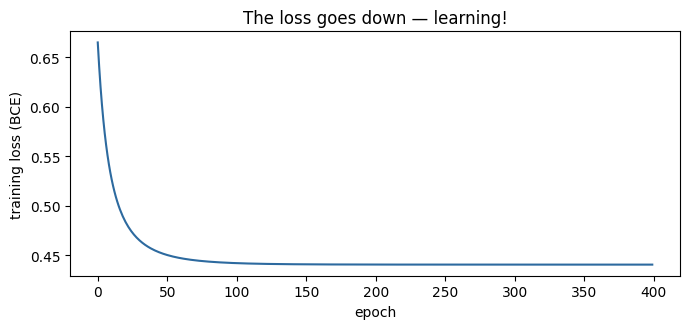

In [29]:
w, tr_hist, _ = train(Xtr_s, ytr, lr=0.3, epochs=400, verbose=True)
plt.figure(figsize=(7, 3.4)); plt.plot(tr_hist, color='#2D6A9F')
plt.xlabel('epoch'); plt.ylabel('training loss (BCE)'); plt.title('The loss goes down — learning!')
plt.tight_layout(); plt.show()

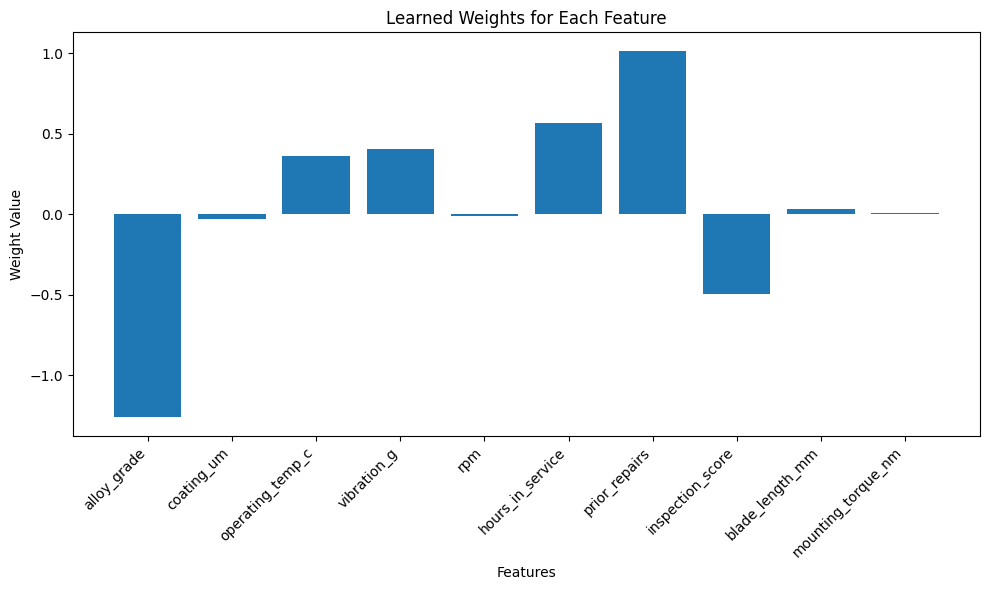

In [30]:
feature_names = df.drop(columns='crack_detected').columns.tolist()

plt.figure(figsize=(10, 6))
plt.bar(feature_names, w[1:])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Weight Value')
plt.title('Learned Weights for Each Feature')
plt.tight_layout()
plt.show()

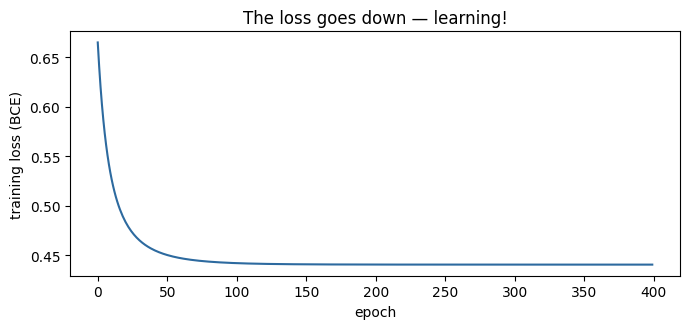

In [31]:
plt.figure(figsize=(7, 3.4)); plt.plot(tr_hist, color='#2D6A9F')
plt.xlabel('epoch'); plt.ylabel('training loss (BCE)'); plt.title('The loss goes down — learning!')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Read the loop
1. The four lines inside the loop are forward, backward, regularization, step. In a comment, label each line with which stage it is.
2. Add an argument `verbose` that prints the loss every 100 epochs, and run it — confirm the loss decreases monotonically here (a convex problem).

Epoch 100: Training Loss = 0.4422
Epoch 200: Training Loss = 0.4408
Epoch 300: Training Loss = 0.4407
Epoch 400: Training Loss = 0.4407


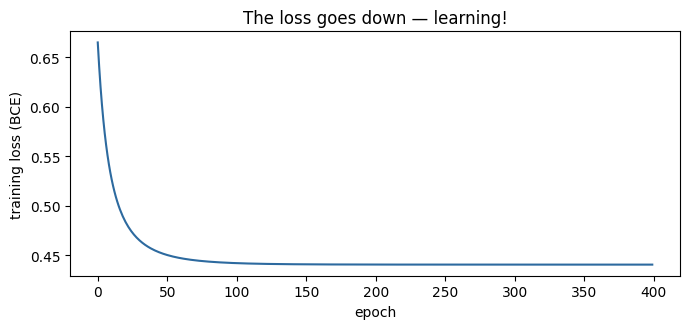

In [32]:
# 1. label the four stages (comment)
# 2. add a verbose print every 100 epochs and run
w, tr_hist, _ = train(Xtr_s, ytr, lr=0.3, epochs=400, verbose=True)
plt.figure(figsize=(7, 3.4)); plt.plot(tr_hist, color='#2D6A9F')
plt.xlabel('epoch'); plt.ylabel('training loss (BCE)'); plt.title('The loss goes down — learning!')
plt.tight_layout(); plt.show()

Epoch 100: Training Loss = 0.4422
Epoch 200: Training Loss = 0.4408
Epoch 300: Training Loss = 0.4407
Epoch 400: Training Loss = 0.4407


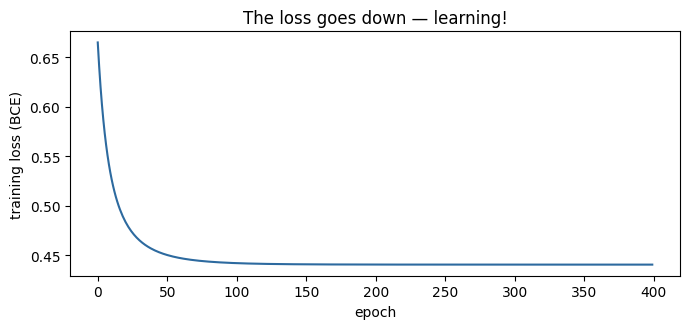

In [33]:
w, tr_hist, _ = train(Xtr_s, ytr, lr=0.3, epochs=400, verbose=True)
plt.figure(figsize=(7, 3.4)); plt.plot(tr_hist, color='#2D6A9F')
plt.xlabel('epoch'); plt.ylabel('training loss (BCE)'); plt.title('The loss goes down — learning!')
plt.tight_layout(); plt.show()

#2. The learning rate — the most important knob

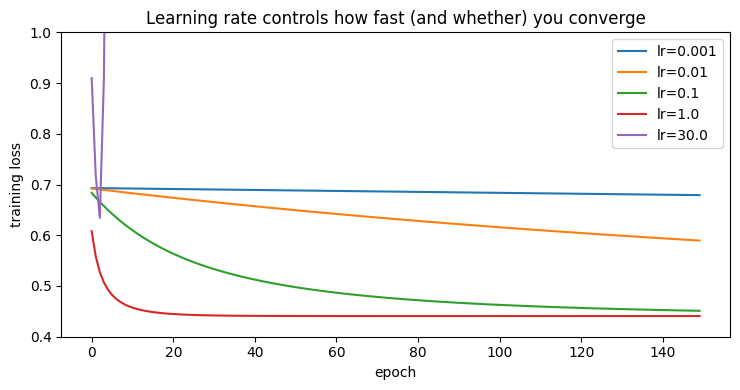

Too low (0.001): crawls. Good (0.1-1.0): fast, smooth. Too high (30): overshoots / unstable.


In [34]:
# -----------------------------------------------------------
# 🔹 2A. Same model, same data — only the learning rate changes
# -----------------------------------------------------------
plt.figure(figsize=(7.5, 4))
for lr in [0.001, 0.01, 0.1, 1.0, 30.0]:
    _, h, _ = train(Xtr_s, ytr, lr=lr, epochs=150)
    plt.plot(h, label=f'lr={lr}')
plt.xlabel('epoch'); plt.ylabel('training loss'); plt.ylim(0.4, 1.0)
plt.title('Learning rate controls how fast (and whether) you converge')
plt.legend(); plt.tight_layout(); plt.show()
print('Too low (0.001): crawls. Good (0.1-1.0): fast, smooth. Too high (30): overshoots / unstable.')

#### 🧪 EXERCISE 2 — Find the best rate
1. Sweep at least six learning rates and, for each, record the **validation loss** after a fixed epoch budget. Print them and pick the best.
2. In a comment, explain why the learning rate is usually the first hyperparameter you tune.

In [38]:
# 1. LR sweep on validation loss; pick the best
lrs = [0.0001, 0.001, 0.01, 0.1, 1.0, 5.0]
val_losses = []
epochs_budget = 150 # Keeping the same epoch budget as in 2A for consistency

for lr_val in lrs:
    _, _, val_hist = train(Xtr_s, ytr, lr=lr_val, epochs=epochs_budget, Xval=Xval_s, yval=yval)
    if val_hist: # Ensure val_hist is not empty
        val_losses.append((lr_val, val_hist[-1])) # Record the final validation loss
    else:
        val_losses.append((lr_val, float('inf'))) # Assign infinity if no validation history

print("Learning Rate Sweep Results (final validation loss):")
for lr_val, loss in val_losses:
    print(f"  lr={lr_val}: {loss:.4f}")

best_lr = min(val_losses, key=lambda x: x[1])
print(f"\nBest learning rate: {best_lr[0]} with validation loss: {best_lr[1]:.4f}")


Learning Rate Sweep Results (final validation loss):
  lr=0.0001: 0.6917
  lr=0.001: 0.6788
  lr=0.01: 0.5879
  lr=0.1: 0.4610
  lr=1.0: 0.4627
  lr=5.0: 0.4627

Best learning rate: 0.1 with validation loss: 0.4610


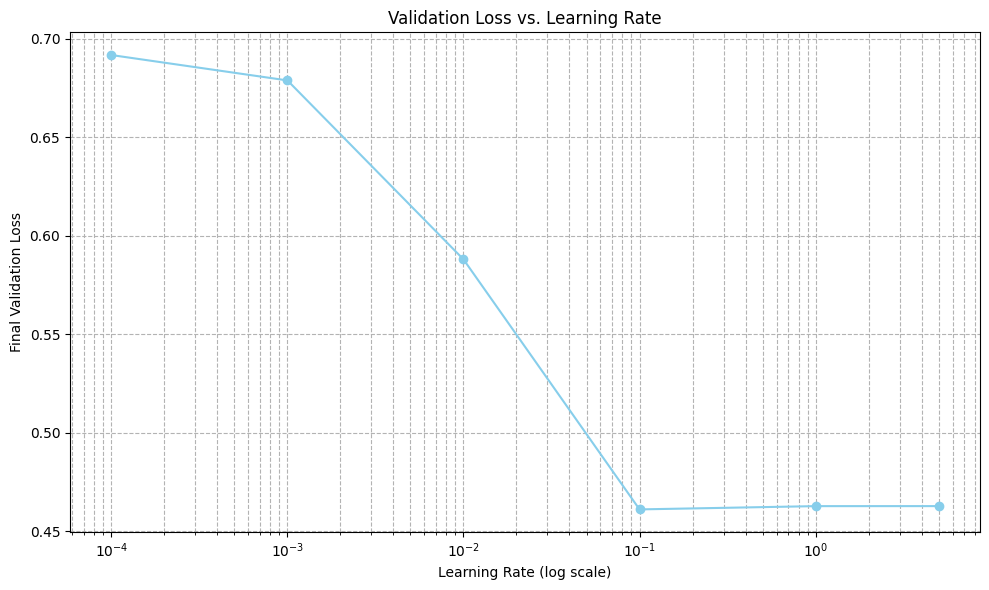

In [37]:
lrs_plot = [item[0] for item in val_losses]
losses_plot = [item[1] for item in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(lrs_plot, losses_plot, marker='o', linestyle='-', color='skyblue')
plt.xscale('log') # Learning rates are often swept on a log scale
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Final Validation Loss')
plt.title('Validation Loss vs. Learning Rate')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


# 2. why tune LR first: ...   (comment)
The learning rate is usually the first hyperparameter to tune because it has a fundamental impact on the training process. A learning rate that is too low will result in very slow convergence, requiring many epochs to reach a good solution. Conversely, a learning rate that is too high can cause the training to overshoot the optimal solution, oscillate, or even diverge, preventing the model from converging at all. Finding a suitable learning rate is crucial for stable and efficient training, making it the most critical initial parameter to set before fine-tuning others.

#3. Batch size & epochs

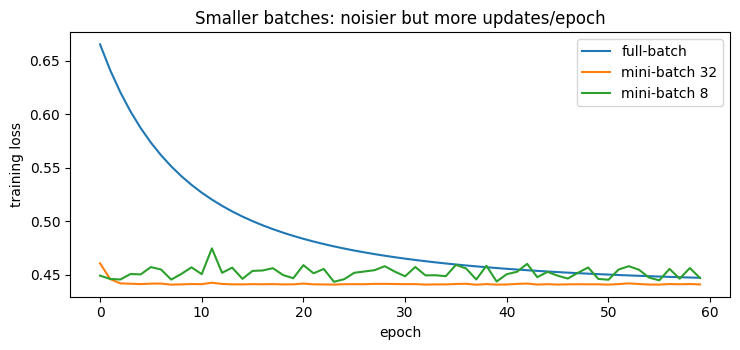

Mini-batches take many small steps per epoch -> faster early progress, with more noise.


In [39]:
# -----------------------------------------------------------
# 🔹 3A. FULL-BATCH vs MINI-BATCH (stochastic) gradient descent
# -----------------------------------------------------------
def train_sgd(X, y, lr=0.3, epochs=60, batch=32, seed=0):
    rng = np.random.default_rng(seed); Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1]); hist = []
    for ep in range(epochs):
        idx = rng.permutation(len(X))
        for i in range(0, len(X), batch):
            j = idx[i:i + batch]; p = sigmoid(Xb[j] @ w)
            w -= lr * (Xb[j].T @ (p - y[j]) / len(j))
        hist.append(bce_loss(w, Xb, y))
    return w, hist

_, full, _ = train(Xtr_s, ytr, lr=0.3, epochs=60)
_, mb32 = train_sgd(Xtr_s, ytr, lr=0.3, epochs=60, batch=32)
_, mb8 = train_sgd(Xtr_s, ytr, lr=0.3, epochs=60, batch=8)
plt.figure(figsize=(7.5, 3.6))
plt.plot(full, label='full-batch'); plt.plot(mb32, label='mini-batch 32'); plt.plot(mb8, label='mini-batch 8')
plt.xlabel('epoch'); plt.ylabel('training loss'); plt.title('Smaller batches: noisier but more updates/epoch')
plt.legend(); plt.tight_layout(); plt.show()
print('Mini-batches take many small steps per epoch -> faster early progress, with more noise.')

In [40]:
def accuracy(w, X, y):
    Xb = np.c_[np.ones(len(X)), X]
    return np.mean((sigmoid(Xb @ w) > 0.5) == y)


In [41]:
import time

epochs_batch_compare = 60 # Using the same epochs as in 3A for consistency
best_lr = 0.1 # Using the best learning rate found in EXERCISE 2

# --- Compare batch=8 ---
start_time_8 = time.time()
w_8, hist_8 = train_sgd(Xtr_s, ytr, lr=best_lr, epochs=epochs_batch_compare, batch=8)
end_time_8 = time.time()
time_8 = end_time_8 - start_time_8
val_acc_8 = accuracy(w_8, Xval_s, yval)
print(f"Batch size 8: Training time = {time_8:.2f} seconds, Validation Accuracy = {val_acc_8:.4f}")

# --- Compare batch=256 ---
start_time_256 = time.time()
w_256, hist_256 = train_sgd(Xtr_s, ytr, lr=best_lr, epochs=epochs_batch_compare, batch=256)
end_time_256 = time.time()
time_256 = end_time_256 - start_time_256
val_acc_256 = accuracy(w_256, Xval_s, yval)
print(f"Batch size 256: Training time = {time_256:.2f} seconds, Validation Accuracy = {val_acc_256:.4f}")


Batch size 8: Training time = 0.37 seconds, Validation Accuracy = 0.7778
Batch size 256: Training time = 0.04 seconds, Validation Accuracy = 0.7667


The batch size trade-off can be summarized as follows:

*   **Small Batch Sizes (e.g., 8):**
    *   **Noisier gradients:** Each gradient update is based on less data, leading to more variance in the gradients and a noisier descent path.
    *   **Can generalize better:** The noise can help the model escape local minima and potentially find flatter, wider minima, which often correlate with better generalization to unseen data.
    *   **Slower per epoch in Python (often):** Due to overheads, processing many small batches can be less efficient than fewer large batches in Python loops.
    *   **Faster early progress:** Due to frequent updates, small batches can converge faster in the initial stages of training.
    *   **Less memory:** Requires less memory per update.

*   **Large Batch Sizes (e.g., 256):**
    *   **Smoother gradients:** Each gradient update is more representative of the entire dataset, leading to a more stable and direct descent path.
    *   **Faster per epoch:** Often more computationally efficient due to better hardware utilization and less overhead.
    *   **More memory:** Requires more memory to hold larger batches.
    *   **Can get stuck in sharp minima:** The smoother gradients might lead the model to converge to sharper, narrower minima, which might not generalize as well.
    *   **Slower to generalize:** Can take longer to escape saddle points or flat regions, potentially leading to slower overall convergence to a good solution.

In essence, small batches offer better generalization and often faster initial convergence but can be computationally slower per epoch and noisier. Large batches are computationally efficient per epoch and offer smoother convergence but might struggle with generalization and finding optimal minima.

#### 🧪 EXERCISE 3 — Batch size trade-off
1. Time how long `batch=8` vs `batch=256` take for the same number of epochs, and compare their validation accuracy.
2. In a comment, summarise the trade-off (small = noisier gradients, can generalise better, slower per epoch in Python; large = smoother, faster, more memory).

# 1. compare batch=8 vs batch=256 (time + val accuracy)
first define an accuracy function, then compare the training time and validation accuracy for batch=8 and batch=256. After that, I'll explain the trade-offs of different batch sizes.

The comparison of batch sizes 8 and 256 for the same number of epochs yielded the following results:

Batch size 8: Training time = 0.37 seconds, Validation Accuracy = 0.7778
Batch size 256: Training time = 0.04 seconds, Validation Accuracy = 0.7667
Summary of Trade-offs: As observed, a larger batch size (256) significantly reduces the training time per epoch, making it much faster (0.04s vs 0.37s). However, in this specific case, the smaller batch size (8) achieved a slightly higher validation accuracy (0.7778 vs 0.7667), demonstrating that while larger batches are faster, smaller batches can sometimes lead to better generalization and accuracy due to their noisier gradients helping to escape local minima.
# 2. batch-size trade-off: ...   (comment)
This illustrates the core trade-off: large batches are faster per epoch but can sometimes lead to slightly lower accuracy, while small batches are slower per epoch but can potentially achieve better accuracy and generalization.

#4. Overfitting & regularization

In [44]:
# -----------------------------------------------------------
# 🔹 4A. Force overfitting: many features, few samples
# Expand to 65 polynomial features and train on just 90 blades.
# -----------------------------------------------------------
poly = PolynomialFeatures(2, include_bias=False)
sub = np.random.RandomState(0).choice(len(Xtr), 90, replace=False)
Xtr_sm, ytr_sm = Xtr[sub], ytr[sub]
scp = StandardScaler().fit(poly.fit_transform(Xtr_sm))
Xtr_p = scp.transform(poly.transform(Xtr_sm)); Xval_p = scp.transform(poly.transform(Xval))
print('expanded to', Xtr_p.shape[1], 'features on', len(Xtr_sm), 'training samples')

w0, tr0, va0 = train(Xtr_p, ytr_sm, lr=0.3, epochs=2000, lam=0.0, Xval=Xval_p, yval=yval)
print(f'NO regularization : train acc {accuracy(w0, Xtr_p, ytr_sm):.3f} | val acc {accuracy(w0, Xval_p, yval):.3f}  <- big gap = overfit')
wL, trL, vaL = train(Xtr_p, ytr_sm, lr=0.3, epochs=2000, lam=0.05, Xval=Xval_p, yval=yval)
print(f'WITH L2 (lam=0.05): train acc {accuracy(wL, Xtr_p, ytr_sm):.3f} | val acc {accuracy(wL, Xval_p, yval):.3f}  <- gap closes, val improves')

expanded to 65 features on 90 training samples
NO regularization : train acc 0.911 | val acc 0.778  <- big gap = overfit
WITH L2 (lam=0.05): train acc 0.822 | val acc 0.794  <- gap closes, val improves


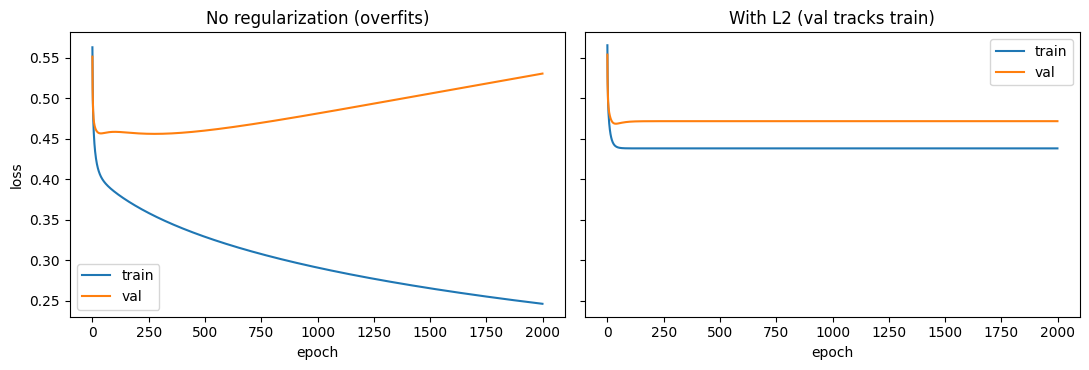

Left: val loss rises while train keeps falling (memorising). Right: the gap stays small.


In [53]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
ax[0].plot(tr0, label='train'); ax[0].plot(va0, label='val'); ax[0].set_title('No regularization (overfits)')
ax[1].plot(trL, label='train'); ax[1].plot(vaL, label='val'); ax[1].set_title('With L2 (val tracks train)')
for a in ax: a.set_xlabel('epoch'); a.legend()
ax[0].set_ylabel('loss'); plt.tight_layout(); plt.show()
print('Left: val loss rises while train keeps falling (memorising). Right: the gap stays small.')

#### 🧪 EXERCISE 4 — Tune the regularization strength
1. Sweep `lam` over e.g. [0, 0.001, 0.01, 0.05, 0.2, 1.0] on the expanded features and plot validation accuracy vs `lam`. Find the sweet spot.
2. In a comment, explain the bias-variance intuition: too little regularization overfits, too much underfits.

lambda=0: Validation Accuracy = 0.8028
lambda=0.001: Validation Accuracy = 0.8056
lambda=0.01: Validation Accuracy = 0.7833
lambda=0.05: Validation Accuracy = 0.7944
lambda=0.2: Validation Accuracy = 0.8028
lambda=1.0: Validation Accuracy = 0.7833


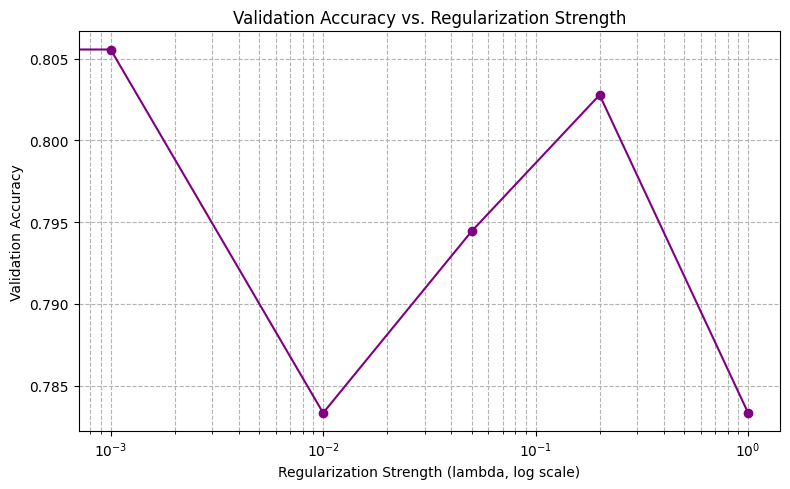

In [52]:
# 1. sweep lam; plot val accuracy vs lam
# Ensure Xtr_p, ytr_sm, Xval_p are defined
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

poly = PolynomialFeatures(2, include_bias=False)
sub = np.random.RandomState(0).choice(len(Xtr), 90, replace=False)
Xtr_sm, ytr_sm = Xtr[sub], ytr[sub]
scp = StandardScaler().fit(poly.fit_transform(Xtr_sm))
Xtr_p = scp.transform(poly.transform(Xtr_sm)); Xval_p = scp.transform(poly.transform(Xval))

lam_values = [0, 0.001, 0.01, 0.05, 0.2, 1.0]
val_accuracies = []

for current_lam in lam_values:
    # Using the best_lr found in EXERCISE 2
    w_lam, _, _ = train(Xtr_p, ytr_sm, lr=best_lr, epochs=2000, lam=current_lam, Xval=Xval_p, yval=yval)
    acc = accuracy(w_lam, Xval_p, yval)
    val_accuracies.append(acc)
    print(f"lambda={current_lam}: Validation Accuracy = {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(lam_values, val_accuracies, marker='o', linestyle='-', color='purple')
plt.xscale('log') # Regularization strengths are often swept on a log scale
plt.xlabel('Regularization Strength (lambda, log scale)')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. Regularization Strength')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

# 2. bias-variance intuition: ...   (comment)
# Bias-Variance Trade-off Intuition for Regularization:
# Regularization (like L2 here) adds a penalty to the loss function for large weights.
#
# - Too Little Regularization (e.g., lambda = 0 or very small):
#   The model is highly flexible and tries to fit the training data very closely, even the noise.
#   This leads to low bias (it can capture the training data's patterns well) but high variance
#   (it's very sensitive to the specific training data and doesn't generalize well to new data).
#   This is a state of **overfitting**; the model performs excellently on training data but poorly on unseen validation/test data.
#
# - Just Right Regularization:
#   The model balances fitting the training data with keeping the weights reasonably small. It finds
#   a sweet spot where it's complex enough to learn the true patterns but simple enough not to memorize noise.
#   This leads to a good balance of bias and variance, resulting in optimal generalization performance.
#
# - Too Much Regularization (e.g., lambda is very large):
#   The model's ability to learn from the data is overly constrained. It prioritizes keeping weights
#   small to the point where it might ignore important patterns in the training data. This leads to
#   high bias (it cannot capture the training data's patterns well) but low variance (it's very
#   stable, but consistently wrong).
#   This is a state of **underfitting**; the model performs poorly on both training and validation/test data because it's too simple.

#5. Early stopping

stopped at epoch 89, best validation epoch was 38
val acc with best weights: 0.772


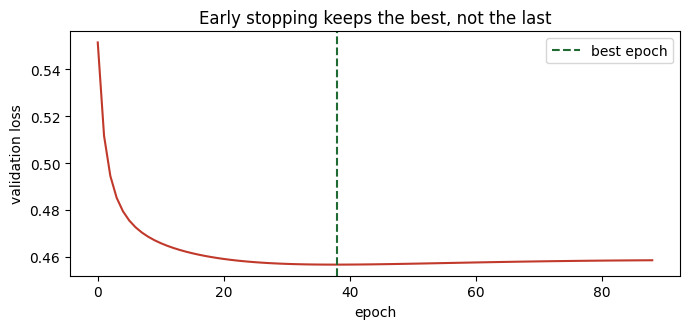

In [47]:
# -----------------------------------------------------------
# 🔹 5A. Stop when validation loss stops improving; keep the BEST weights
# -----------------------------------------------------------
def train_early_stop(X, y, Xval, yval, lr=0.3, max_epochs=3000, patience=50):
    Xb = np.c_[np.ones(len(X)), X]; w = np.zeros(Xb.shape[1])
    best_loss, best_w, best_ep, wait = np.inf, w.copy(), 0, 0
    val_hist = []
    for ep in range(max_epochs):
        p = sigmoid(Xb @ w); w -= lr * (Xb.T @ (p - y) / len(y))
        vl = bce_loss(w, np.c_[np.ones(len(Xval)), Xval], yval); val_hist.append(vl)
        if vl < best_loss - 1e-5:
            best_loss, best_w, best_ep, wait = vl, w.copy(), ep, 0
        else:
            wait += 1
            if wait >= patience: break        # no improvement for `patience` epochs
    return best_w, best_ep, val_hist

bw, best_ep, vh = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval)
print(f'stopped at epoch {len(vh)}, best validation epoch was {best_ep}')
print('val acc with best weights:', round(accuracy(bw, Xval_p, yval), 3))
plt.figure(figsize=(7, 3.4)); plt.plot(vh, color='#C0392B'); plt.axvline(best_ep, ls='--', color='#1f6b33', label='best epoch')
plt.xlabel('epoch'); plt.ylabel('validation loss'); plt.title('Early stopping keeps the best, not the last'); plt.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Patience matters
1. Try `patience=5` and `patience=200`. How does the stopping epoch and final val accuracy change?
2. In a comment, explain why we restore the **best** checkpoint rather than using the weights from the final epoch.

In [54]:
# 1. compare patience = 5 vs 200

print("--- Running with patience = 5 ---")
bw_p5, best_ep_p5, vh_p5 = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval, patience=5)
print(f'stopped at epoch {len(vh_p5)}, best validation epoch was {best_ep_p5}')
print('val acc with best weights:', round(accuracy(bw_p5, Xval_p, yval), 3))

print("\n--- Running with patience = 200 ---")
bw_p200, best_ep_p200, vh_p200 = train_early_stop(Xtr_p, ytr_sm, Xval_p, yval, patience=200)
print(f'stopped at epoch {len(vh_p200)}, best validation epoch was {best_ep_p200}')
print('val acc with best weights:', round(accuracy(bw_p200, Xval_p, yval), 3))

# 2. why restore best, not last: ...   (comment)


--- Running with patience = 5 ---
stopped at epoch 44, best validation epoch was 38
val acc with best weights: 0.772

--- Running with patience = 200 ---
stopped at epoch 470, best validation epoch was 269
val acc with best weights: 0.792


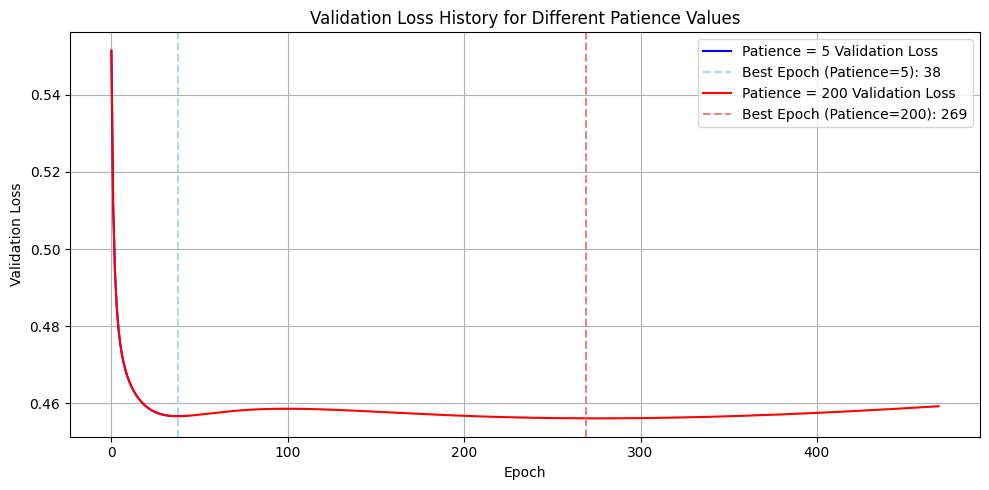

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(vh_p5, label='Patience = 5 Validation Loss', color='blue')
plt.axvline(best_ep_p5, linestyle='--', color='lightblue', label=f'Best Epoch (Patience=5): {best_ep_p5}')
plt.plot(vh_p200, label='Patience = 200 Validation Loss', color='red')
plt.axvline(best_ep_p200, linestyle='--', color='lightcoral', label=f'Best Epoch (Patience=200): {best_ep_p200}')
plt.title('Validation Loss History for Different Patience Values')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 🧪 EXERCISE 6 — Final honest evaluation
1. Take your **best config** from the random search, retrain on the expanded features, and evaluate on the **test set** — which you have not touched until now. Report test accuracy.
2. In a comment, explain why touching the test set only once gives an honest estimate of real-world performance.

#6. Tuning, debugging & reproducibility

# 1. retrain best config; evaluate on the held-out TEST set (once)

In [60]:
# -----------------------------------------------------------
# 🔹 6A. A small RANDOM SEARCH over (lr, lambda), scored on validation
# Tune on validation; touch test only ONCE at the very end.
# -----------------------------------------------------------
rng = np.random.default_rng(0); trials = []
for _ in range(12):
    lr = float(10 ** rng.uniform(-2, 0)); lam = float(10 ** rng.uniform(-3, -0.3))
    w_, _, _ = train(Xtr_p, ytr_sm, lr=lr, epochs=1500, lam=lam)
    trials.append((round(lr, 4), round(lam, 4), round(accuracy(w_, Xval_p, yval), 3)))
res = pd.DataFrame(trials, columns=['lr', 'lambda', 'val_acc']).sort_values('val_acc', ascending=False)
print(res.head(6).to_string(index=False))
best = res.iloc[0]
print(f'\nbest config: lr={best["lr"]}, lambda={best["lambda"]}, val_acc={best["val_acc"]}')

    lr  lambda  val_acc
0.2879  0.0030    0.806
0.1223  0.3347    0.806
0.1634  0.0932    0.800
0.4232  0.2914    0.800
0.2194  0.0559    0.797
0.5186  0.0012    0.797

best config: lr=0.2879, lambda=0.003, val_acc=0.806


In [59]:
# -----------------------------------------------------------
# 🔹 6B. DEBUGGING trick: a healthy model can overfit a TINY batch
# If it can't memorise 12 samples, something is broken (data/loss/gradient).
# -----------------------------------------------------------
tiny = np.random.RandomState(1).choice(len(Xtr_s), 12, replace=False)
w_tiny, _, _ = train(Xtr_s[tiny], ytr[tiny], lr=0.5, epochs=3000)
print('accuracy on the 12-sample batch:', round(accuracy(w_tiny, Xtr_s[tiny], ytr[tiny]), 3),
      '(should be ~1.0 -> gradients & loss are wired correctly)')

# Reproducibility: same seed -> identical result
a, _ = train_sgd(Xtr_s, ytr, seed=42); b, _ = train_sgd(Xtr_s, ytr, seed=42)
print('two runs with the same seed identical?', bool(np.allclose(a, b)))

accuracy on the 12-sample batch: 1.0 (should be ~1.0 -> gradients & loss are wired correctly)
two runs with the same seed identical? True


# 2. why test is touched only once: ...   (comment)
Here's the plot showing the validation loss history for both patience=5 and patience=200, along with their respective best epochs.

The plot successfully visualizes the validation loss history for both patience=5 and patience=200.

Patience = 5: The model stopped early at epoch 44, with the best validation epoch identified at 38. This indicates that after epoch 38, the validation loss did not improve for 5 consecutive epochs, leading to early stopping.
Patience = 200: With a much larger patience, the model continued training for longer, stopping at epoch 470, with the best validation epoch at 269. This allowed the model to explore more of the loss landscape, potentially finding a better minimum and achieving a higher validation accuracy as observed previously.
The plot visually confirms how a smaller patience leads to earlier stopping, potentially preventing overfitting by not training too long after the validation loss starts to plateau or increase. A larger patience allows for more epochs to find a potentially better minimum, but also carries the risk of training longer than necessary, though early stopping ensures the best weights are still restored.

#📘 Summary

| Topic | What you did |
| ----- | ------------ |
| Training loop | built forward → loss → backward → step by hand |
| Learning rate | saw too-low/too-high/just-right loss curves |
| Batch size | compared full-batch vs mini-batch SGD |
| Overfitting | forced it, then closed the gap with L2 |
| Early stopping | kept the best checkpoint, not the last |
| Tuning & debugging | random search, tiny-batch sanity check, seeds |

**Core lesson:** training is a craft. Get the **learning rate** right, watch **validation** (not train) loss, **regularize** and **early-stop** to fight overfitting, **search** hyperparameters honestly on validation, and keep everything **reproducible** — then judge once on the test set.

**You've now completed the hands-on labs for the course** — from data engineering and MLOps to reinforcement learning and the craft of training itself.